In [1]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.preprocessing import LabelEncoder

In [2]:
original_dataset_path = "ecg dataset 4 classes"
cropped_dir = "cropped_ecg"
os.makedirs(
    cropped_dir,
    exist_ok=True
)
data = []

import os
print(os.listdir(original_dataset_path))

def crop_ecg_region(img):

    h, w = img.shape[:2]
    cropped = img[ int(0.20*h):int(0.96*h),
                   int(0.04*w):int(0.98*w)]
                                     
    return cropped

['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'Normal Person ECG Images (284x12=3408)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'ECG Images of Patient that have History of MI (172x12=2064)']


In [3]:
import os

fold_root = "5FoldDataset"

all_images = []

for fold in os.listdir(fold_root):

    fold_path = os.path.join(
        fold_root,
        fold
    )

    for cls in os.listdir(fold_path):

        class_path = os.path.join(
            fold_path,
            cls
        )

        for img in os.listdir(class_path):

            all_images.append(
                f"{cls}/{img}"
            )

print(
    "Total Images:",
    len(all_images)
)

print(
    "Unique Images:",
    len(set(all_images))
)

Total Images: 928
Unique Images: 928


In [4]:
import os

fold_root = "5FoldDataset"

for fold in sorted(os.listdir(fold_root)):

    print(f"\n{fold}")

    total = 0

    fold_path = os.path.join(
        fold_root,
        fold
    )

    for cls in sorted(os.listdir(fold_path)):

        class_path = os.path.join(
            fold_path,
            cls
        )

        count = len(
            os.listdir(class_path)
        )

        total += count

        print(
            f"{cls}: {count}"
        )

    print(
        f"Total Images: {total}"
    )


Fold1
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 35
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 47
Normal Person ECG Images (284x12=3408): 57
Total Images: 187

Fold2
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 35
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 47
Normal Person ECG Images (284x12=3408): 57
Total Images: 187

Fold3
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 34
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 47
Normal Person ECG Images (284x12=3408): 57
Total Images: 186

Fold4
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 34
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 46
Norma

In [5]:
from tqdm import tqdm
import os

data = []

for label in os.listdir(cropped_dir):

    class_folder = os.path.join(
        cropped_dir,
        label
    )

    if not os.path.isdir(class_folder):
        continue

    print(f"\nCollecting: {label}")

    for img_name in tqdm(
        os.listdir(class_folder),
        desc=label
    ):

        img_path = os.path.join(
            class_folder,
            img_name
        )

        data.append(
            [
                img_path,
                label
            ]
        )

print("Data Collection Complete")


Collecting: ECG Images of Myocardial Infarction Patients (240x12=2880)


ECG Images of Myocardial Infarction Patients (240x12=2880): 100%|██████████| 239/239 [00:00<00:00, 794325.40it/s]



Collecting: Normal Person ECG Images (284x12=3408)


Normal Person ECG Images (284x12=3408): 100%|██████████| 284/284 [00:00<00:00, 579368.84it/s]



Collecting: ECG Images of Patient that have abnormal heartbeat (233x12=2796)


ECG Images of Patient that have abnormal heartbeat (233x12=2796): 100%|██████████| 233/233 [00:00<00:00, 838860.80it/s]



Collecting: ECG Images of Patient that have History of MI (172x12=2064)


ECG Images of Patient that have History of MI (172x12=2064): 100%|██████████| 172/172 [00:00<00:00, 788437.47it/s]

Data Collection Complete


In [6]:
import pandas as pd
df = pd.DataFrame(
    data,
    columns=[
        "image_path",
        "label"
    ]
)

In [7]:
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['encoded_label'] = encoder.fit_transform(
    df['label']
)

In [8]:
label_mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(
            encoder.classes_
        )
    )
)

print(label_mapping)

{'ECG Images of Myocardial Infarction Patients (240x12=2880)': 0, 'ECG Images of Patient that have History of MI (172x12=2064)': 1, 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 2, 'Normal Person ECG Images (284x12=3408)': 3}


In [9]:
df.to_csv(
    "ecg_dataset.csv",
    index=False
)

print(
    "CSV Saved Successfully"
)

CSV Saved Successfully


In [10]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cpu


In [11]:
import torch
import torch.nn as nn

from torchvision import transforms
from torchvision import models

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image

In [12]:
IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [13]:
class ECGDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]['image_path']

        label = self.df.iloc[idx]['encoded_label']

        image = Image.open(
            img_path
        ).convert('RGB')

        if self.transform:

            image = self.transform(image)

        return image, label

In [14]:
from collections import defaultdict

class EpisodeDataset:

    def __init__(self, dataframe, transform=None):

        self.transform = transform

        self.class_to_images = defaultdict(list)

        for _, row in dataframe.iterrows():

            self.class_to_images[
                row["encoded_label"]
            ].append(
                row["image_path"]
            )

        self.classes = sorted(
            list(
                self.class_to_images.keys()
            )
        )

    def get_classes(self):

        return self.classes

    def get_images(self, class_id):

        return self.class_to_images[class_id]

    def __len__(self):

        return sum(
            len(v)
            for v in self.class_to_images.values()
        )

In [15]:
episode_dataset = EpisodeDataset(
    df,
    transform=train_transform
)

print(
    episode_dataset.get_classes()
)

for cls in episode_dataset.get_classes():

    print(
        f"Class {cls} ->",
        len(
            episode_dataset.get_images(cls)
        ),
        "images"
    )

[0, 1, 2, 3]
Class 0 -> 239 images
Class 1 -> 172 images
Class 2 -> 233 images
Class 3 -> 284 images


In [16]:
import random
import torch
from PIL import Image

class EpisodeSampler:

    def __init__(
        self,
        episode_dataset,
        transform,
        n_way=4,
        n_support=5,
        n_query=5
    ):

        self.dataset = episode_dataset
        self.transform = transform

        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query

        self.classes = self.dataset.get_classes()

    def sample_episode(self):

        selected_classes = random.sample(
            self.classes,
            self.n_way
        )

        support_images = []
        support_labels = []

        query_images = []
        query_labels = []

        for new_label, class_id in enumerate(selected_classes):

            image_list = self.dataset.get_images(class_id)

            chosen = random.sample(
                image_list,
                self.n_support + self.n_query
            )

            support_paths = chosen[:self.n_support]
            query_paths = chosen[self.n_support:]

            for img_path in support_paths:

                image = Image.open(img_path).convert("RGB")

                image = self.transform(image)

                support_images.append(image)

                support_labels.append(new_label)

            for img_path in query_paths:

                image = Image.open(img_path).convert("RGB")

                image = self.transform(image)

                query_images.append(image)

                query_labels.append(new_label)

        support_images = torch.stack(support_images)
        query_images = torch.stack(query_images)

        support_labels = torch.tensor(support_labels)
        query_labels = torch.tensor(query_labels)

        return (
            support_images,
            support_labels,
            query_images,
            query_labels
        )

In [17]:
episode_sampler = EpisodeSampler(
    episode_dataset,
    transform=train_transform,
    n_way=4,
    n_support=5,
    n_query=5
)

support_images, support_labels, query_images, query_labels = \
episode_sampler.sample_episode()

print(support_images.shape)
print(query_images.shape)

print(support_labels)
print(query_labels)

torch.Size([20, 3, 224, 224])
torch.Size([20, 3, 224, 224])
tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3])
tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3])


In [18]:
import torch
import torch.nn as nn
from torchvision import models


class ProtoBackbone(nn.Module):

    def __init__(self, backbone_name):

        super().__init__()

        self.backbone_name = backbone_name

        #################################################
        # DenseNet169
        #################################################

        if backbone_name == "DenseNet169":

            backbone = models.densenet169(
                weights="DEFAULT"
            )

            self.features = backbone.features

            self.pool = nn.AdaptiveAvgPool2d((1,1))

            self.embedding_dim = 1664

        #################################################
        # ResNet50
        #################################################

        elif backbone_name == "ResNet50":

            backbone = models.resnet50(
                weights="DEFAULT"
            )

            self.features = nn.Sequential(
                *list(backbone.children())[:-2]
            )

            self.pool = nn.AdaptiveAvgPool2d((1,1))

            self.embedding_dim = 2048

        #################################################
        # VGG16
        #################################################

        elif backbone_name == "VGG16":

            backbone = models.vgg16(
                weights="DEFAULT"
            )

            self.features = backbone.features

            self.pool = nn.AdaptiveAvgPool2d((7,7))

            self.embedding_dim = 512 * 7 * 7

        #################################################
        # VGG19
        #################################################

        elif backbone_name == "VGG19":

            backbone = models.vgg19(
                weights="DEFAULT"
            )

            self.features = backbone.features

            self.pool = nn.AdaptiveAvgPool2d((7,7))

            self.embedding_dim = 512 * 7 * 7

        #################################################
        # MobileNetV2
        #################################################

        elif backbone_name == "MobileNetV2":

            backbone = models.mobilenet_v2(
                weights="DEFAULT"
            )

            self.features = backbone.features

            self.pool = nn.AdaptiveAvgPool2d((1,1))

            self.embedding_dim = 1280

        else:

            raise ValueError(
                f"Unknown Backbone: {backbone_name}"
            )


    #####################################################

    def forward(self,x):

        x = self.features(x)

        x = torch.relu(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        return x

In [19]:
backbone_names = [

    "DenseNet169",

    "ResNet50",

    "VGG16",

    "VGG19",

    "MobileNetV2"

]

models_dict = {}

for name in backbone_names:

    models_dict[name] = ProtoBackbone(name)

In [20]:
for name, model in models_dict.items():

    print(
        name,
        model.embedding_dim
    )

DenseNet169 1664
ResNet50 2048
VGG16 25088
VGG19 25088
MobileNetV2 1280


In [21]:
###########################################################
# Stage 4 : Prototype Computation
###########################################################

def compute_prototypes(
    embeddings,
    labels,
    n_way
):
    """
    embeddings : Tensor
                 shape -> [N_support, embedding_dim]

    labels : Tensor
             shape -> [N_support]

    n_way : number of classes

    returns:
        prototypes
        shape -> [n_way, embedding_dim]
    """

    prototypes = []

    for cls in range(n_way):

        cls_embeddings = embeddings[
            labels == cls
        ]

        prototype = cls_embeddings.mean(
            dim=0
        )

        prototypes.append(prototype)

    prototypes = torch.stack(
        prototypes,
        dim=0
    )

    return prototypes

In [22]:
# Dummy Example

embeddings = torch.randn(
    20,
    1664
)

labels = torch.tensor(

    [0]*5 +
    [1]*5 +
    [2]*5 +
    [3]*5

)

prototypes = compute_prototypes(

    embeddings,

    labels,

    n_way=4

)

print(prototypes.shape)

torch.Size([4, 1664])


In [23]:
############################################################
# Pairwise Euclidean Distance
############################################################

def pairwise_distance(query_embeddings,
                      prototypes):

    """
    query_embeddings :
        (num_query, embedding_dim)

    prototypes :
        (n_way, embedding_dim)

    returns
        distances :
        (num_query, n_way)
    """

    distances = torch.cdist(
        query_embeddings,
        prototypes,
        p=2
    )

    return distances

In [24]:
query = torch.randn(
    20,
    1664
)

prototypes = torch.randn(
    4,
    1664
)

dist = pairwise_distance(
    query,
    prototypes
)

print(dist.shape)

torch.Size([20, 4])


In [25]:
###########################################################
# Stage 6 : Prototypical Loss
###########################################################

import torch
import torch.nn.functional as F


def prototypical_loss(
    support_embeddings,
    support_labels,
    query_embeddings,
    query_labels,
    n_way
):
    """
    Compute ProtoNet loss and episode accuracy.
    """

    ##################################################
    # Compute prototypes
    ##################################################

    prototypes = compute_prototypes(
        support_embeddings,
        support_labels,
        n_way
    )

    ##################################################
    # Distances
    ##################################################

    distances = pairwise_distance(
        query_embeddings,
        prototypes
    )

    ##################################################
    # Negative distance -> logits
    ##################################################

    logits = -distances

    ##################################################
    # Cross entropy
    ##################################################

    loss = F.cross_entropy(
        logits,
        query_labels
    )

    ##################################################
    # Episode Accuracy
    ##################################################

    preds = torch.argmax(
        logits,
        dim=1
    )

    acc = (
        preds == query_labels
    ).float().mean()

    return loss, acc

In [26]:
support_embeddings = torch.randn(
    20,
    1664
)

query_embeddings = torch.randn(
    20,
    1664
)

support_labels = torch.tensor(
    [0]*5 +
    [1]*5 +
    [2]*5 +
    [3]*5
)

query_labels = torch.tensor(
    [0]*5 +
    [1]*5 +
    [2]*5 +
    [3]*5
)

loss, acc = prototypical_loss(
    support_embeddings,
    support_labels,
    query_embeddings,
    query_labels,
    n_way=4
)

print(loss.item())
print(acc.item())

1.4342777729034424
0.20000000298023224


In [27]:
# ###########################################################
# # Stage 7 : train_protonet()
# ###########################################################

import copy
import torch
import numpy as np


# def train_protonet(
#     model,
#     train_sampler,
#     val_sampler,
#     test_sampler,
#     optimizer,
#     device,
#     epochs=50,
#     episodes_per_epoch=20,
#     save_path=None
# ):

#     train_losses = []
#     train_accs = []

#     val_losses = []
#     val_accs = []

#     test_losses = []
#     test_accs = []

#     best_val_acc = 0.0

#     best_model = copy.deepcopy(
#         model.state_dict()
#     )

#     ####################################################
#     # Epoch Loop
#     ####################################################

#     for epoch in range(epochs):

#         ################################################
#         # TRAINING
#         ################################################

#         model.train()

#         epoch_train_loss = 0
#         epoch_train_acc = 0

#         for episode in range(
#             episodes_per_epoch
#         ):

#             (
#                 support_images,
#                 support_labels,
#                 query_images,
#                 query_labels
#             ) = train_sampler.sample_episode()

#             support_images = support_images.to(device)
#             support_labels = support_labels.to(device)

#             query_images = query_images.to(device)
#             query_labels = query_labels.to(device)

#             optimizer.zero_grad()

#             ############################################

#             support_embeddings = model(
#                 support_images
#             )

#             query_embeddings = model(
#                 query_images
#             )

#             ############################################

#             loss, acc = prototypical_loss(

#                 support_embeddings,

#                 support_labels,

#                 query_embeddings,

#                 query_labels,

#                 train_sampler.n_way

#             )

#             ############################################

#             loss.backward()

#             optimizer.step()

#             ############################################

#             epoch_train_loss += loss.item()

#             epoch_train_acc += acc.item()

#         ################################################

#         epoch_train_loss /= episodes_per_epoch

#         epoch_train_acc /= episodes_per_epoch

#         ################################################
#         # VALIDATION
#         ################################################

#         model.eval()

#         epoch_val_loss = 0
#         epoch_val_acc = 0

#         with torch.no_grad():

#             for episode in range(
#                 episodes_per_epoch
#             ):

#                 (
#                     support_images,
#                     support_labels,
#                     query_images,
#                     query_labels
#                 ) = val_sampler.sample_episode()

#                 support_images = support_images.to(device)
#                 support_labels = support_labels.to(device)

#                 query_images = query_images.to(device)
#                 query_labels = query_labels.to(device)

#                 support_embeddings = model(
#                     support_images
#                 )

#                 query_embeddings = model(
#                     query_images
#                 )

#                 loss, acc = prototypical_loss(

#                     support_embeddings,

#                     support_labels,

#                     query_embeddings,

#                     query_labels,

#                     val_sampler.n_way

#                 )

#                 epoch_val_loss += loss.item()

#                 epoch_val_acc += acc.item()

#         epoch_val_loss /= episodes_per_epoch

#         epoch_val_acc /= episodes_per_epoch

#         ################################################
#         # TEST
#         ################################################

#         epoch_test_loss = 0
#         epoch_test_acc = 0

#         with torch.no_grad():

#             for episode in range(
#                 episodes_per_epoch
#             ):

#                 (
#                     support_images,
#                     support_labels,
#                     query_images,
#                     query_labels
#                 ) = test_sampler.sample_episode()

#                 support_images = support_images.to(device)
#                 support_labels = support_labels.to(device)

#                 query_images = query_images.to(device)
#                 query_labels = query_labels.to(device)

#                 support_embeddings = model(
#                     support_images
#                 )

#                 query_embeddings = model(
#                     query_images
#                 )

#                 loss, acc = prototypical_loss(

#                     support_embeddings,

#                     support_labels,

#                     query_embeddings,

#                     query_labels,

#                     test_sampler.n_way

#                 )

#                 epoch_test_loss += loss.item()

#                 epoch_test_acc += acc.item()

#         epoch_test_loss /= episodes_per_epoch

#         epoch_test_acc /= episodes_per_epoch

#         ################################################
#         # STORE HISTORY
#         ################################################

#         train_losses.append(
#             epoch_train_loss
#         )

#         train_accs.append(
#             epoch_train_acc
#         )

#         val_losses.append(
#             epoch_val_loss
#         )

#         val_accs.append(
#             epoch_val_acc
#         )

#         test_losses.append(
#             epoch_test_loss
#         )

#         test_accs.append(
#             epoch_test_acc
#         )

#         ################################################
#         # SAVE BEST MODEL
#         ################################################

#         if epoch_val_acc > best_val_acc:
#             best_val_acc = epoch_val_acc
#             best_model = copy.deepcopy(model.state_dict())
        
#             if save_path is not None:
#                 torch.save(best_model, save_path)

#         ################################################

#         print(

#             f"Epoch {epoch+1:03d} | "

#             f"Train Loss {epoch_train_loss:.4f} "

#             f"Train Acc {epoch_train_acc*100:.2f}% | "

#             f"Val Loss {epoch_val_loss:.4f} "

#             f"Val Acc {epoch_val_acc*100:.2f}% | "

#             f"Test Loss {epoch_test_loss:.4f} "

#             f"Test Acc {epoch_test_acc*100:.2f}%"

#         )

#     ####################################################
#     # Load Best Epoch
#     ####################################################

#     model.load_state_dict(best_model)
#     if save_path is not None:torch.save(best_model,save_path)

#     return (

#         train_losses,
#         train_accs,

#         val_losses,
#         val_accs,

#         test_losses,
#         test_accs,

#         model

#     )
def train_protonet(
    model,
    train_sampler,
    val_sampler,
    test_sampler,
    optimizer,
    device,
    epochs=50,
    episodes_per_epoch=20,
    save_path=None
):

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    test_losses = []
    test_accs = []

    best_val_acc = -1.0
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        model.train()
        epoch_train_loss = 0.0
        epoch_train_acc = 0.0

        for _ in range(episodes_per_epoch):

            support_images, support_labels, query_images, query_labels = train_sampler.sample_episode()

            support_images = support_images.to(device)
            support_labels = support_labels.to(device)
            query_images = query_images.to(device)
            query_labels = query_labels.to(device)

            optimizer.zero_grad()

            support_embeddings = model(support_images)
            query_embeddings = model(query_images)

            loss, acc = prototypical_loss(
                support_embeddings,
                support_labels,
                query_embeddings,
                query_labels,
                train_sampler.n_way
            )

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_acc += acc.item()

        epoch_train_loss /= episodes_per_epoch
        epoch_train_acc /= episodes_per_epoch

        model.eval()
        epoch_val_loss = 0.0
        epoch_val_acc = 0.0

        with torch.no_grad():
            for _ in range(episodes_per_epoch):

                support_images, support_labels, query_images, query_labels = val_sampler.sample_episode()

                support_images = support_images.to(device)
                support_labels = support_labels.to(device)
                query_images = query_images.to(device)
                query_labels = query_labels.to(device)

                support_embeddings = model(support_images)
                query_embeddings = model(query_images)

                loss, acc = prototypical_loss(
                    support_embeddings,
                    support_labels,
                    query_embeddings,
                    query_labels,
                    val_sampler.n_way
                )

                epoch_val_loss += loss.item()
                epoch_val_acc += acc.item()

        epoch_val_loss /= episodes_per_epoch
        epoch_val_acc /= episodes_per_epoch

        epoch_test_loss = 0.0
        epoch_test_acc = 0.0

        with torch.no_grad():
            for _ in range(episodes_per_epoch):

                support_images, support_labels, query_images, query_labels = test_sampler.sample_episode()

                support_images = support_images.to(device)
                support_labels = support_labels.to(device)
                query_images = query_images.to(device)
                query_labels = query_labels.to(device)

                support_embeddings = model(support_images)
                query_embeddings = model(query_images)

                loss, acc = prototypical_loss(
                    support_embeddings,
                    support_labels,
                    query_embeddings,
                    query_labels,
                    test_sampler.n_way
                )

                epoch_test_loss += loss.item()
                epoch_test_acc += acc.item()

        epoch_test_loss /= episodes_per_epoch
        epoch_test_acc /= episodes_per_epoch

        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)
        test_losses.append(epoch_test_loss)
        test_accs.append(epoch_test_acc)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model = copy.deepcopy(model.state_dict())
            if save_path is not None:
                torch.save(best_model, save_path)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss {epoch_train_loss:.4f} Train Acc {epoch_train_acc*100:.2f}% | "
            f"Val Loss {epoch_val_loss:.4f} Val Acc {epoch_val_acc*100:.2f}% | "
            f"Test Loss {epoch_test_loss:.4f} Test Acc {epoch_test_acc*100:.2f}%"
        )

    model.load_state_dict(best_model)
    if save_path is not None:
        torch.save(best_model, save_path)

    return (
        train_losses,
        train_accs,
        val_losses,
        val_accs,
        test_losses,
        test_accs,
        model
    )

In [28]:
from sklearn.model_selection import train_test_split
import os
import pandas as pd
import numpy as np
import copy
import torch
import torch.optim as optim

def build_fold_dfs_from_root(
    fold_root,
    fold_idx,
    val_size=0.15,
    seed=42,
    save_csv=True
):
    """
    Creates train / val / test dataframes for one fold
    using the existing 5-fold folder structure.
    """

    train_data = []
    test_data = []

    test_fold_name = f"Fold{fold_idx + 1}"
    test_folder = os.path.join(fold_root, test_fold_name)

    # test fold
    for label in os.listdir(test_folder):
        label_folder = os.path.join(test_folder, label)
        if not os.path.isdir(label_folder):
            continue
        for img in os.listdir(label_folder):
            test_data.append([
                os.path.join(label_folder, img),
                label
            ])

    # train folds = all other folds
    for other_fold in range(5):
        if other_fold == fold_idx:
            continue

        train_folder = os.path.join(fold_root, f"Fold{other_fold + 1}")

        for label in os.listdir(train_folder):
            label_folder = os.path.join(train_folder, label)
            if not os.path.isdir(label_folder):
                continue
            for img in os.listdir(label_folder):
                train_data.append([
                    os.path.join(label_folder, img),
                    label
                ])

    train_df = pd.DataFrame(train_data, columns=["image_path", "label"])
    test_df = pd.DataFrame(test_data, columns=["image_path", "label"])

    train_df["encoded_label"] = encoder.transform(train_df["label"])
    test_df["encoded_label"] = encoder.transform(test_df["label"])

    train_df, val_df = train_test_split(
        train_df,
        test_size=val_size,
        random_state=seed,
        stratify=train_df["encoded_label"]
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    if save_csv:
        train_df.to_csv(f"train_df_fold{fold_idx + 1}.csv", index=False)
        val_df.to_csv(f"val_df_fold{fold_idx + 1}.csv", index=False)
        test_df.to_csv(f"test_df_fold{fold_idx + 1}.csv", index=False)

    return train_df, val_df, test_df

In [29]:
# def train_backbone_protonet(
#     backbone_name,
#     fold_root,
#     device,
#     epochs=50,
#     episodes_per_epoch=20,
#     lr=1e-4,
#     n_way=4,
#     n_support=5,
#     n_query=5
# ):
#     """
#     Trains one backbone with ProtoNet across 5 folds.
#     """

#     backbone_histories = {}
#     backbone_models = {}
#     fold_summary = []

#     for fold in range(5):

#         print("\n" + "=" * 70)
#         print(f"{backbone_name} | Fold {fold + 1}")
#         print("=" * 70)

#         train_df, val_df, test_df = build_fold_dfs_from_root(
#             fold_root=fold_root,
#             fold_idx=fold,
#             val_size=0.15,
#             seed=42,
#             save_csv=True
#         )

#         train_episode_dataset = EpisodeDataset(train_df)
#         val_episode_dataset = EpisodeDataset(val_df)
#         test_episode_dataset = EpisodeDataset(test_df)

#         train_sampler = EpisodeSampler(
#             train_episode_dataset,
#             train_transform,
#             n_way=n_way,
#             n_support=n_support,
#             n_query=n_query
#         )

#         val_sampler = EpisodeSampler(
#             val_episode_dataset,
#             test_transform,
#             n_way=n_way,
#             n_support=n_support,
#             n_query=n_query
#         )

#         test_sampler = EpisodeSampler(
#             test_episode_dataset,
#             test_transform,
#             n_way=n_way,
#             n_support=n_support,
#             n_query=n_query
#         )

#         model = ProtoBackbone(backbone_name).to(device)

#         optimizer = optim.Adam(
#             model.parameters(),
#             lr=lr
#         )
        
#         save_name = f"{backbone_name}_ProtoNet_fold{fold + 1}.pth"

#         train_losses, train_accs, val_losses, val_accs, test_losses, test_accs, model = train_protonet(
#             model=model,
#             train_sampler=train_sampler,
#             val_sampler=val_sampler,
#             test_sampler=test_sampler,
#             optimizer=optimizer,
#             device=device,
#             epochs=epochs,
#             episodes_per_epoch=episodes_per_epoch,
#             save_path=save_name
#         )

#         backbone_histories[f"Fold{fold + 1}"] = {
#             "train_losses": train_losses,
#             "train_accs": train_accs,
#             "val_losses": val_losses,
#             "val_accs": val_accs,
#             "test_losses": test_losses,
#             "test_accs": test_accs
#         }

#         backbone_models[f"Fold{fold + 1}"] = copy.deepcopy(model)

#         fold_summary.append({
#             "Fold": fold + 1,
#             "BestValAcc": float(np.max(val_accs)),
#             "BestTestAccAtBestVal": float(test_accs[int(np.argmax(val_accs))]),
#             "FinalTrainAcc": float(train_accs[-1]),
#             "FinalValAcc": float(val_accs[-1]),
#             "FinalTestAcc": float(test_accs[-1]),
#         })

#     return backbone_histories, backbone_models, pd.DataFrame(fold_summary)

def train_backbone_protonet(
    backbone_name,
    fold_root,
    device,
    epochs=50,
    episodes_per_epoch=20,
    lr=1e-4,
    n_way=4,
    n_support=5,
    n_query=5
):
    backbone_histories = {}
    backbone_models = {}
    fold_summary = []

    for fold in range(5):

        print("\n" + "=" * 70)
        print(f"{backbone_name} | Fold {fold + 1}")
        print("=" * 70)

        train_df, val_df, test_df = build_fold_dfs_from_root(
            fold_root=fold_root,
            fold_idx=fold,
            val_size=0.15,
            seed=42,
            save_csv=True
        )

        train_episode_dataset = EpisodeDataset(train_df)
        val_episode_dataset = EpisodeDataset(val_df)
        test_episode_dataset = EpisodeDataset(test_df)

        train_sampler = EpisodeSampler(
            train_episode_dataset,
            train_transform,
            n_way=n_way,
            n_support=n_support,
            n_query=n_query
        )

        val_sampler = EpisodeSampler(
            val_episode_dataset,
            test_transform,
            n_way=n_way,
            n_support=n_support,
            n_query=n_query
        )

        test_sampler = EpisodeSampler(
            test_episode_dataset,
            test_transform,
            n_way=n_way,
            n_support=n_support,
            n_query=n_query
        )

        model = ProtoBackbone(backbone_name).to(device)

        optimizer = optim.Adam(model.parameters(), lr=lr)

        save_name = f"{backbone_name}_ProtoNet_fold{fold + 1}.pth"

        train_losses, train_accs, val_losses, val_accs, test_losses, test_accs, model = train_protonet(
            model=model,
            train_sampler=train_sampler,
            val_sampler=val_sampler,
            test_sampler=test_sampler,
            optimizer=optimizer,
            device=device,
            epochs=epochs,
            episodes_per_epoch=episodes_per_epoch,
            save_path=save_name
        )

        backbone_histories[f"Fold{fold + 1}"] = {
            "train_losses": train_losses,
            "train_accs": train_accs,
            "val_losses": val_losses,
            "val_accs": val_accs,
            "test_losses": test_losses,
            "test_accs": test_accs
        }

        backbone_models[f"Fold{fold + 1}"] = copy.deepcopy(model)

        fold_summary.append({
            "Fold": fold + 1,
            "BestValAcc": float(np.max(val_accs)),
            "BestTestAccAtBestVal": float(test_accs[int(np.argmax(val_accs))]),
            "FinalTrainAcc": float(train_accs[-1]),
            "FinalValAcc": float(val_accs[-1]),
            "FinalTestAcc": float(test_accs[-1]),
        })

    return backbone_histories, backbone_models, pd.DataFrame(fold_summary)

In [30]:
from collections import Counter

for fold in range(5):

    print("="*60)
    print(f"Fold {fold+1}")
    print("="*60)

    train_df, val_df, test_df = build_fold_dfs_from_root(
        fold_root=fold_root,
        fold_idx=fold,
        val_size=0.15,
        seed=42,
        save_csv=False
    )

    print("\nTRAIN")

    print(
        Counter(
            train_df["encoded_label"]
        )
    )

    print("\nVALIDATION")

    print(
        Counter(
            val_df["encoded_label"]
        )
    )

    print("\nTEST")

    print(
        Counter(
            test_df["encoded_label"]
        )
    )

    print()

Fold 1

TRAIN
Counter({3: 193, 0: 162, 2: 158, 1: 116})

VALIDATION
Counter({3: 34, 0: 29, 2: 28, 1: 21})

TEST
Counter({3: 57, 0: 48, 2: 47, 1: 35})

Fold 2

TRAIN
Counter({3: 193, 0: 162, 2: 158, 1: 116})

VALIDATION
Counter({3: 34, 0: 29, 2: 28, 1: 21})

TEST
Counter({3: 57, 0: 48, 2: 47, 1: 35})

Fold 3

TRAIN
Counter({3: 193, 0: 162, 2: 158, 1: 117})

VALIDATION
Counter({3: 34, 0: 29, 2: 28, 1: 21})

TEST
Counter({3: 57, 0: 48, 2: 47, 1: 34})

Fold 4

TRAIN
Counter({3: 193, 0: 162, 2: 159, 1: 117})

VALIDATION
Counter({3: 34, 0: 29, 2: 28, 1: 21})

TEST
Counter({3: 57, 0: 48, 2: 46, 1: 34})

Fold 5

TRAIN
Counter({3: 194, 0: 163, 2: 159, 1: 117})

VALIDATION
Counter({3: 34, 0: 29, 2: 28, 1: 21})

TEST
Counter({3: 56, 0: 47, 2: 46, 1: 34})



In [31]:
for fold in range(5):

    train_df, val_df, test_df = build_fold_dfs_from_root(
        fold_root=fold_root,
        fold_idx=fold,
        save_csv=False
    )

    print(
        f"Fold {fold+1}"
    )

    print(
        train_df.groupby(
            "encoded_label"
        ).size().min()
    )

    print(
        val_df.groupby(
            "encoded_label"
        ).size().min()
    )

    print(
        test_df.groupby(
            "encoded_label"
        ).size().min()
    )

    print()

Fold 1
116
21
35

Fold 2
116
21
35

Fold 3
117
21
34

Fold 4
117
21
34

Fold 5
117
21
34



In [32]:
master_histories = {}
master_saved_models = {}
master_fold_summaries = {}
master_results = []

In [33]:
# BACKBONES = [
#     "DenseNet169",
#     "ResNet50",
#     "VGG16",
#     "VGG19",
#     "MobileNetV2"
# ]

# all_histories = {}
# all_saved_models = {}
# all_fold_summaries = {}
# results = []

# for backbone_name in BACKBONES:
#     histories, saved_models, summary_df = train_backbone_protonet(
#         backbone_name=backbone_name,
#         fold_root=fold_root,
#         device=device,
#         epochs=50,
#         episodes_per_epoch=20,
#         lr=1e-4,
#         n_way=4,
#         n_support=5,
#         n_query=5
#     )

#     all_histories[backbone_name] = histories
#     all_saved_models[backbone_name] = saved_models
#     all_fold_summaries[backbone_name] = summary_df

#     results.append({
#         "Model": backbone_name,
#         "Mean Best Val Acc": summary_df["BestValAcc"].mean(),
#         "Std Best Val Acc": summary_df["BestValAcc"].std()
#     })

# results = pd.DataFrame(results)
# display(results)
# results.to_csv("ProtoNet_Backbone_Results.csv", index=False)

###########################################################
# Stage 9 : Debug Training (Single Backbone)
###########################################################

BACKBONE = "DenseNet169"

histories, saved_models, summary_df = train_backbone_protonet(
    backbone_name=BACKBONE,
    fold_root=fold_root,
    device=device,

    # ---------- DEBUG ----------
    epochs=50,
    episodes_per_epoch=20,
    # ---------------------------

    lr=1e-4,
    n_way=4,
    n_support=5,
    n_query=5
)

master_histories[BACKBONE] = histories
master_saved_models[BACKBONE] = saved_models
master_fold_summaries[BACKBONE] = summary_df
print(summary_df)

import pickle

with open(f"{BACKBONE}_history.pkl", "wb") as f:
    pickle.dump(histories, f)

print(f"{BACKBONE}_history.pkl saved successfully.")

summary_df.to_csv(
    f"{BACKBONE}_FoldSummary.csv",
    index=False
)

In [34]:
BACKBONE = "ResNet50"

histories, saved_models, summary_df = train_backbone_protonet(
    backbone_name=BACKBONE,
    fold_root=fold_root,
    device=device,

    # ---------- DEBUG ----------
    epochs=50,
    episodes_per_epoch=20,
    # ---------------------------

    lr=1e-4,
    n_way=4,
    n_support=5,
    n_query=5
)

master_histories[BACKBONE] = histories
master_saved_models[BACKBONE] = saved_models
master_fold_summaries[BACKBONE] = summary_df

print(summary_df)


ResNet50 | Fold 1
Epoch 001 | Train Loss 1.1364 Train Acc 55.50% | Val Loss 1.0129 Val Acc 58.25% | Test Loss 1.0217 Test Acc 60.50%
Epoch 002 | Train Loss 0.6538 Train Acc 77.25% | Val Loss 0.3863 Val Acc 85.25% | Test Loss 0.4533 Test Acc 84.50%
Epoch 003 | Train Loss 0.3608 Train Acc 88.50% | Val Loss 0.3373 Val Acc 88.75% | Test Loss 0.3501 Test Acc 88.50%
Epoch 004 | Train Loss 0.2301 Train Acc 92.50% | Val Loss 0.3265 Val Acc 89.00% | Test Loss 0.3040 Test Acc 88.50%
Epoch 005 | Train Loss 0.1638 Train Acc 94.75% | Val Loss 0.2038 Val Acc 93.00% | Test Loss 0.1273 Test Acc 95.25%
Epoch 006 | Train Loss 0.1145 Train Acc 95.50% | Val Loss 0.2039 Val Acc 93.25% | Test Loss 0.1048 Test Acc 96.50%
Epoch 007 | Train Loss 0.1145 Train Acc 96.75% | Val Loss 0.2189 Val Acc 93.75% | Test Loss 0.2302 Test Acc 93.50%
Epoch 008 | Train Loss 0.0575 Train Acc 98.25% | Val Loss 0.2710 Val Acc 91.00% | Test Loss 0.1636 Test Acc 96.25%
Epoch 009 | Train Loss 0.1013 Train Acc 97.75% | Val Loss 0.2

In [35]:
BACKBONE = "VGG16"

histories, saved_models, summary_df = train_backbone_protonet(
    backbone_name=BACKBONE,
    fold_root=fold_root,
    device=device,

    # ---------- DEBUG ----------
    epochs=50,
    episodes_per_epoch=20,
    # ---------------------------

    lr=1e-4,
    n_way=4,
    n_support=5,
    n_query=5
)

master_histories[BACKBONE] = histories
master_saved_models[BACKBONE] = saved_models
master_fold_summaries[BACKBONE] = summary_df

print(summary_df)


VGG16 | Fold 1
Epoch 001 | Train Loss 1.5150 Train Acc 59.00% | Val Loss 0.6078 Val Acc 77.75% | Test Loss 0.4865 Test Acc 80.75%
Epoch 002 | Train Loss 0.4386 Train Acc 85.50% | Val Loss 0.4080 Val Acc 84.75% | Test Loss 0.4678 Test Acc 81.50%
Epoch 003 | Train Loss 0.4247 Train Acc 84.75% | Val Loss 0.3341 Val Acc 89.25% | Test Loss 0.2080 Test Acc 93.25%
Epoch 004 | Train Loss 0.2552 Train Acc 91.50% | Val Loss 0.2621 Val Acc 90.25% | Test Loss 0.1566 Test Acc 95.00%
Epoch 005 | Train Loss 0.1759 Train Acc 94.50% | Val Loss 0.1719 Val Acc 94.25% | Test Loss 0.2451 Test Acc 93.25%
Epoch 006 | Train Loss 0.2658 Train Acc 92.00% | Val Loss 0.2216 Val Acc 93.75% | Test Loss 0.2201 Test Acc 94.00%
Epoch 007 | Train Loss 0.2281 Train Acc 93.25% | Val Loss 0.4005 Val Acc 86.00% | Test Loss 0.2492 Test Acc 92.75%
Epoch 008 | Train Loss 0.1225 Train Acc 95.75% | Val Loss 0.1785 Val Acc 94.50% | Test Loss 0.1049 Test Acc 96.75%
Epoch 009 | Train Loss 0.1336 Train Acc 96.00% | Val Loss 0.1457

In [37]:
BACKBONE = "VGG19"

histories, saved_models, summary_df = train_backbone_protonet(
    backbone_name=BACKBONE,
    fold_root=fold_root,
    device=device,

    # ---------- DEBUG ----------
    epochs=50,
    episodes_per_epoch=20,
    # ---------------------------

    lr=1e-4,
    n_way=4,
    n_support=5,
    n_query=5
)

master_histories[BACKBONE] = histories
master_saved_models[BACKBONE] = saved_models
master_fold_summaries[BACKBONE] = summary_df

print(summary_df)


VGG19 | Fold 1
Epoch 001 | Train Loss 1.7506 Train Acc 55.00% | Val Loss 0.5937 Val Acc 75.25% | Test Loss 0.5457 Test Acc 81.75%
Epoch 002 | Train Loss 0.5244 Train Acc 81.50% | Val Loss 0.3863 Val Acc 89.50% | Test Loss 0.4226 Test Acc 87.75%
Epoch 003 | Train Loss 0.3356 Train Acc 90.75% | Val Loss 0.4036 Val Acc 86.75% | Test Loss 0.2585 Test Acc 92.25%
Epoch 004 | Train Loss 0.3206 Train Acc 89.50% | Val Loss 0.3512 Val Acc 86.75% | Test Loss 0.1660 Test Acc 95.00%
Epoch 005 | Train Loss 0.1705 Train Acc 95.25% | Val Loss 0.2504 Val Acc 89.00% | Test Loss 0.2526 Test Acc 91.75%
Epoch 006 | Train Loss 0.1737 Train Acc 93.50% | Val Loss 0.2450 Val Acc 91.00% | Test Loss 0.1762 Test Acc 94.00%
Epoch 007 | Train Loss 0.1224 Train Acc 95.25% | Val Loss 0.2122 Val Acc 91.00% | Test Loss 0.2038 Test Acc 94.25%
Epoch 008 | Train Loss 0.2011 Train Acc 93.00% | Val Loss 0.1528 Val Acc 94.25% | Test Loss 0.1363 Test Acc 95.75%
Epoch 009 | Train Loss 0.1359 Train Acc 95.50% | Val Loss 0.1186

In [38]:
BACKBONE = "MobileNetV2"

histories, saved_models, summary_df = train_backbone_protonet(
    backbone_name=BACKBONE,
    fold_root=fold_root,
    device=device,

    # ---------- DEBUG ----------
    epochs=50,
    episodes_per_epoch=20,
    # ---------------------------

    lr=1e-4,
    n_way=4,
    n_support=5,
    n_query=5
)

master_histories[BACKBONE] = histories
master_saved_models[BACKBONE] = saved_models
master_fold_summaries[BACKBONE] = summary_df

print(summary_df)


MobileNetV2 | Fold 1
Epoch 001 | Train Loss 1.2136 Train Acc 46.50% | Val Loss 1.0973 Val Acc 55.75% | Test Loss 1.0413 Test Acc 62.00%
Epoch 002 | Train Loss 1.0479 Train Acc 56.75% | Val Loss 0.8996 Val Acc 64.00% | Test Loss 0.8109 Test Acc 68.75%
Epoch 003 | Train Loss 0.7700 Train Acc 72.25% | Val Loss 0.7338 Val Acc 72.00% | Test Loss 0.6189 Test Acc 77.75%
Epoch 004 | Train Loss 0.5859 Train Acc 77.00% | Val Loss 0.6426 Val Acc 74.50% | Test Loss 0.5135 Test Acc 79.00%
Epoch 005 | Train Loss 0.5222 Train Acc 81.25% | Val Loss 0.4597 Val Acc 83.50% | Test Loss 0.4378 Test Acc 82.50%
Epoch 006 | Train Loss 0.4268 Train Acc 84.25% | Val Loss 0.4321 Val Acc 86.25% | Test Loss 0.3547 Test Acc 86.50%
Epoch 007 | Train Loss 0.3341 Train Acc 86.50% | Val Loss 0.3625 Val Acc 87.75% | Test Loss 0.2533 Test Acc 91.25%
Epoch 008 | Train Loss 0.2655 Train Acc 91.50% | Val Loss 0.3220 Val Acc 90.75% | Test Loss 0.1830 Test Acc 93.25%
Epoch 009 | Train Loss 0.2036 Train Acc 92.75% | Val Loss 

In [33]:
def load_master_saved_models_from_disk(backbones, device):
    master_saved_models = {}

    for backbone_name in backbones:
        master_saved_models[backbone_name] = {}

        for fold in range(5):
            model = ProtoBackbone(backbone_name).to(device)
            ckpt_path = f"{backbone_name}_ProtoNet_fold{fold+1}.pth"

            state_dict = torch.load(ckpt_path, map_location=device)
            model.load_state_dict(state_dict)
            model.eval()

            master_saved_models[backbone_name][f"Fold{fold+1}"] = model

    return master_saved_models

In [34]:
BACKBONES = ["DenseNet169", "ResNet50", "VGG16", "VGG19", "MobileNetV2"]
master_saved_models = load_master_saved_models_from_disk(BACKBONES, device)
print(master_saved_models.keys())

dict_keys(['DenseNet169', 'ResNet50', 'VGG16', 'VGG19', 'MobileNetV2'])


In [35]:
# ###########################################################
# # Stage 9 : evaluate_protonet()
# ###########################################################

# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     confusion_matrix,
#     cohen_kappa_score
# )

# import numpy as np
# import torch


# def evaluate_protonet(
#     model,
#     sampler,
#     device,
#     episodes=100
# ):
#     """
#     Evaluate ProtoNet on multiple episodes.

#     Returns
#     -------
#     accuracy
#     precision
#     recall
#     f1
#     kappa
#     confusion_matrix
#     """

#     model.eval()

#     all_predictions = []
#     all_labels = []

#     with torch.no_grad():

#         for _ in range(episodes):

#             (
#                 support_images,
#                 support_labels,
#                 query_images,
#                 query_labels
#             ) = sampler.sample_episode()

#             support_images = support_images.to(device)
#             support_labels = support_labels.to(device)

#             query_images = query_images.to(device)
#             query_labels = query_labels.to(device)

#             ####################################################
#             # Embeddings
#             ####################################################

#             support_embeddings = model(
#                 support_images
#             )

#             query_embeddings = model(
#                 query_images
#             )

#             ####################################################
#             # Prototypes
#             ####################################################

#             prototypes = compute_prototypes(
#                 support_embeddings,
#                 support_labels,
#                 n_way=len(torch.unique(support_labels))
#             )

#             ####################################################
#             # Distances
#             ####################################################

#             distances = pairwise_distance(
#                 query_embeddings,
#                 prototypes
#             )

#             ####################################################
#             # Prediction
#             ####################################################

#             preds = torch.argmin(
#                 distances,
#                 dim=1
#             )

#             all_predictions.extend(
#                 preds.cpu().numpy()
#             )

#             all_labels.extend(
#                 query_labels.cpu().numpy()
#             )

#     ########################################################
#     # Metrics
#     ########################################################

#     accuracy = accuracy_score(
#         all_labels,
#         all_predictions
#     )

#     precision = precision_score(
#         all_labels,
#         all_predictions,
#         average="macro",
#         zero_division=0
#     )

#     recall = recall_score(
#         all_labels,
#         all_predictions,
#         average="macro",
#         zero_division=0
#     )

#     f1 = f1_score(
#         all_labels,
#         all_predictions,
#         average="macro",
#         zero_division=0
#     )

#     kappa = cohen_kappa_score(
#         all_labels,
#         all_predictions
#     )

#     cm = confusion_matrix(
#         all_labels,
#         all_predictions
#     )

#     return (
#         accuracy,
#         precision,
#         recall,
#         f1,
#         kappa,
#         cm
#     )

###########################################################
# Stage 10 : evaluate_protonet_fixed_support()
###########################################################

import torch
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

def evaluate_protonet_fixed_support(
    model,
    train_df,
    test_df,
    device,
    n_support=5,
    support_transform=None,
    query_transform=None,
    seed=42
):
    model = model.to(device)
    model.eval()
    """
    Final fold-level evaluation for ProtoNet.

    Uses a fixed support set sampled from the training split,
    then classifies every image in the test split exactly once.

    Returns
    -------
    accuracy, precision, recall, f1, kappa, cm, y_true, y_pred
    """

    model.eval()

    if support_transform is None or query_transform is None:
        raise ValueError(
            "support_transform and query_transform must be provided."
        )

    ###########################################################
    # Fixed class order
    ###########################################################
    class_order = sorted(train_df["encoded_label"].unique())
    n_way = len(class_order)

    ###########################################################
    # Build one fixed support set per class
    ###########################################################
    support_images = []
    support_labels = []

    for local_label, class_id in enumerate(class_order):

        cls_df = train_df[
            train_df["encoded_label"] == class_id
        ]

        sampled_df = cls_df.sample(
            n=n_support,
            random_state=seed,
            replace=False
        )

        for img_path in sampled_df["image_path"].tolist():

            img = Image.open(img_path).convert("RGB")
            img = support_transform(img)

            support_images.append(img)
            support_labels.append(local_label)

    support_images = torch.stack(support_images).to(device)
    support_labels = torch.tensor(
        support_labels,
        dtype=torch.long,
        device=device
    )

    ###########################################################
    # Compute prototypes ONCE
    ###########################################################
    with torch.no_grad():

        support_embeddings = model(support_images)

        prototypes = compute_prototypes(
            support_embeddings,
            support_labels,
            n_way=n_way
        )

    ###########################################################
    # Predict EVERY test image exactly once
    ###########################################################
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for _, row in test_df.iterrows():

            img_path = row["image_path"]
            true_label = int(row["encoded_label"])

            img = Image.open(img_path).convert("RGB")
            img = query_transform(img).unsqueeze(0).to(device)

            query_embedding = model(img)

            distances = pairwise_distance(
                query_embedding,
                prototypes
            )

            pred_label = torch.argmin(
                distances,
                dim=1
            ).item()

            all_predictions.append(pred_label)
            all_labels.append(true_label)

    ###########################################################
    # Metrics
    ###########################################################
    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_predictions
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=list(range(n_way))
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        kappa,
        cm,
        all_labels,
        all_predictions
    )

In [36]:
def evaluate_all_backbones_protonet(
    master_saved_models,
    fold_root,
    device,
    n_support=5,
    support_transform=None,
    query_transform=None,
    seed=42
):
    """
    Evaluate all backbones across all 5 folds.
    Returns:
      results_df: mean±std metrics per backbone
      confusion_matrices: full 928-image cm per backbone
      fold_metrics: per-fold metric table per backbone
    """

    all_results = []
    confusion_matrices = {}
    fold_metrics = {}

    for backbone_name, fold_models in master_saved_models.items():

        print("\n" + "=" * 80)
        print(f"Evaluating {backbone_name}")
        print("=" * 80)

        backbone_fold_rows = []
        y_true_all = []
        y_pred_all = []

        for fold in range(5):

            print(f"  Fold {fold+1}")

            train_df, val_df, test_df = build_fold_dfs_from_root(
                fold_root=fold_root,
                fold_idx=fold,
                val_size=0.15,
                seed=seed,
                save_csv=False
            )

            model = fold_models[f"Fold{fold+1}"]

            acc, prec, rec, f1, kappa, cm, y_true, y_pred = evaluate_protonet_fixed_support(
                model=model,
                train_df=train_df,
                test_df=test_df,
                device=device,
                n_support=n_support,
                support_transform=support_transform,
                query_transform=query_transform,
                seed=seed
            )

            backbone_fold_rows.append({
                "Fold": fold + 1,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1,
                "Kappa": kappa
            })

            y_true_all.extend(y_true)
            y_pred_all.extend(y_pred)

        fold_df = pd.DataFrame(backbone_fold_rows)
        fold_metrics[backbone_name] = fold_df

        cm_928 = confusion_matrix(
            y_true_all,
            y_pred_all,
            labels=[0, 1, 2, 3]
        )
        confusion_matrices[backbone_name] = cm_928

        all_results.append({
            "Model": backbone_name,
            "Accuracy Mean": fold_df["Accuracy"].mean(),
            "Accuracy Std": fold_df["Accuracy"].std(),
            "Precision Mean": fold_df["Precision"].mean(),
            "Precision Std": fold_df["Precision"].std(),
            "Recall Mean": fold_df["Recall"].mean(),
            "Recall Std": fold_df["Recall"].std(),
            "F1 Mean": fold_df["F1"].mean(),
            "F1 Std": fold_df["F1"].std(),
            "Kappa Mean": fold_df["Kappa"].mean(),
            "Kappa Std": fold_df["Kappa"].std()
        })

    results_df = pd.DataFrame(all_results)
    return results_df, confusion_matrices, fold_metrics

In [47]:
# train_df, val_df, test_df = build_fold_dfs_from_root(
#     fold_root=fold_root,
#     fold_idx=0,
#     val_size=0.15,
#     seed=42,
#     save_csv=False
# )

# acc, prec, rec, f1, kappa, cm, y_true, y_pred = evaluate_protonet_fixed_support(
#     model=model,
#     train_df=train_df,
#     test_df=test_df,
#     device=device,
#     n_support=5,
#     support_transform=test_transform,
#     query_transform=test_transform
# )

# print(acc, prec, rec, f1, kappa)
# print(cm)
results_df, confusion_matrices, fold_metrics = evaluate_all_backbones_protonet(
    master_saved_models=master_saved_models,
    fold_root=fold_root,
    device=device,
    n_support=5,
    support_transform=test_transform,
    query_transform=test_transform,
    seed=42
)

display(results_df)


Evaluating DenseNet169
  Fold 1
  Fold 2
  Fold 3
  Fold 4
  Fold 5

Evaluating ResNet50
  Fold 1
  Fold 2
  Fold 3
  Fold 4
  Fold 5

Evaluating VGG16
  Fold 1
  Fold 2
  Fold 3
  Fold 4
  Fold 5

Evaluating VGG19
  Fold 1
  Fold 2
  Fold 3
  Fold 4
  Fold 5

Evaluating MobileNetV2
  Fold 1
  Fold 2
  Fold 3
  Fold 4
  Fold 5


,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,Kappa Mean,Kappa Std
0,DenseNet169,0.978400,0.014784,0.978104,0.015009,0.977736,0.013803,0.977538,0.014440,0.970923,0.019869
1,ResNet50,0.971907,0.016924,0.973164,0.015030,0.969998,0.017858,0.970420,0.017251,0.962132,0.022832
2,VGG16,0.977325,0.007240,0.976913,0.004433,0.976305,0.008149,0.976119,0.006050,0.969451,0.009806
3,VGG19,0.975151,0.013182,0.975444,0.010943,0.972789,0.013914,0.973805,0.012705,0.966497,0.017809
4,MobileNetV2,0.969774,0.012513,0.969439,0.013075,0.967086,0.013140,0.967038,0.013822,0.959283,0.016855


In [48]:
paper_df = results_df.copy()

paper_df["Accuracy"] = paper_df.apply(
    lambda r: f"{r['Accuracy Mean']*100:.2f} ± {r['Accuracy Std']*100:.2f}", axis=1
)
paper_df["Precision"] = paper_df.apply(
    lambda r: f"{r['Precision Mean']*100:.2f} ± {r['Precision Std']*100:.2f}", axis=1
)
paper_df["Recall"] = paper_df.apply(
    lambda r: f"{r['Recall Mean']*100:.2f} ± {r['Recall Std']*100:.2f}", axis=1
)
paper_df["F1"] = paper_df.apply(
    lambda r: f"{r['F1 Mean']*100:.2f} ± {r['F1 Std']*100:.2f}", axis=1
)
paper_df["Kappa"] = paper_df.apply(
    lambda r: f"{r['Kappa Mean']:.4f} ± {r['Kappa Std']:.4f}", axis=1
)

paper_df = paper_df[["Model", "Accuracy", "Precision", "Recall", "F1", "Kappa"]]
display(paper_df)

,Model,Accuracy,Precision,Recall,F1,Kappa
0,DenseNet169,97.84 ± 1.48,97.81 ± 1.50,97.77 ± 1.38,97.75 ± 1.44,0.9709 ± 0.0199
1,ResNet50,97.19 ± 1.69,97.32 ± 1.50,97.00 ± 1.79,97.04 ± 1.73,0.9621 ± 0.0228
2,VGG16,97.73 ± 0.72,97.69 ± 0.44,97.63 ± 0.81,97.61 ± 0.60,0.9695 ± 0.0098
3,VGG19,97.52 ± 1.32,97.54 ± 1.09,97.28 ± 1.39,97.38 ± 1.27,0.9665 ± 0.0178
4,MobileNetV2,96.98 ± 1.25,96.94 ± 1.31,96.71 ± 1.31,96.70 ± 1.38,0.9593 ± 0.0169


In [39]:
class_names = [
    "MI",
    "H.MI",
    "AH",
    "NP"
]

In [40]:
###############################################################
# Stage 10 : Final Evaluation (Paper Results)
###############################################################

import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)


def evaluate_backbone_protonet(
    backbone_name,
    device,
    n_support=5
):

    fold_metrics = []

    global_predictions = []
    global_labels = []

    for fold in range(5):

        print(f"\nEvaluating {backbone_name} | Fold {fold+1}")

        ###################################################
        # Load Fold Data
        ###################################################

        train_df = pd.read_csv(f"train_df_fold{fold+1}.csv")
        test_df  = pd.read_csv(f"test_df_fold{fold+1}.csv")

        ###################################################
        # Restore encoded labels
        ###################################################

        train_df["encoded_label"] = encoder.transform(
            train_df["label"]
        )

        test_df["encoded_label"] = encoder.transform(
            test_df["label"]
        )

        ###################################################
        # Load Fold Model
        ###################################################

        model = ProtoBackbone(backbone_name).to(device)

        model.load_state_dict(

            torch.load(

                f"{backbone_name}_ProtoNet_fold{fold+1}.pth",

                map_location=device

            )

        )

        model.eval()

        ###################################################
        # Evaluate Fold
        ###################################################

        (
            acc,
            prec,
            rec,
            f1,
            kappa,
            cm,
            y_true,
            y_pred

        ) = evaluate_protonet_fixed_support(

            model=model,

            train_df=train_df,

            test_df=test_df,

            device=device,

            n_support=n_support,

            support_transform=test_transform,

            query_transform=test_transform

        )

        ###################################################
        # Store Fold Metrics
        ###################################################

        fold_metrics.append({

            "Accuracy":acc,

            "Precision":prec,

            "Recall":rec,

            "F1":f1,

            "Kappa":kappa

        })

        ###################################################
        # Global Predictions
        ###################################################

        global_predictions.extend(y_pred)

        global_labels.extend(y_true)

    ###########################################################
    # Global Confusion Matrix
    ###########################################################

    global_predictions=np.array(global_predictions)

    global_labels=np.array(global_labels)

    cm=confusion_matrix(

        global_labels,

        global_predictions

    )

    ###########################################################
    # Mean ± Std
    ###########################################################

    metrics_df=pd.DataFrame(fold_metrics)

    summary={

        "Model":backbone_name,

        "Accuracy Mean":metrics_df["Accuracy"].mean(),

        "Accuracy Std":metrics_df["Accuracy"].std(),

        "Precision Mean":metrics_df["Precision"].mean(),

        "Precision Std":metrics_df["Precision"].std(),

        "Recall Mean":metrics_df["Recall"].mean(),

        "Recall Std":metrics_df["Recall"].std(),

        "F1 Mean":metrics_df["F1"].mean(),

        "F1 Std":metrics_df["F1"].std(),

        "Kappa Mean":metrics_df["Kappa"].mean(),

        "Kappa Std":metrics_df["Kappa"].std()

    }

    ###########################################################
    # Plot
    ###########################################################

    plt.figure(figsize=(8,8))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="YlGn",

        xticklabels=class_names,

        yticklabels=class_names,

        linewidths=1,

        linecolor="black",

        square=True,

        cbar=False,

        annot_kws={"size":38}

    )

    plt.xlabel(

        "Predicted",

        fontsize=40

    )

    plt.ylabel(

        "Ground Truth",

        fontsize=40

    )

    plt.xticks(

        rotation=30,

        fontsize=40

    )

    plt.yticks(

        rotation=30,

        fontsize=40

    )

    plt.tight_layout()

    plt.savefig(

        f"{backbone_name}_ConfusionMatrix.png",

        dpi=600,

        bbox_inches="tight"

    )
    plt.show()
    plt.close()

    return summary,cm

In [45]:
# BACKBONES=[

#     "DenseNet169",

#     "ResNet50",

#     "VGG16",

#     "VGG19",

#     "MobileNetV2"

# ]

# paper_results=[]

# confusion_matrices={}

# for backbone in BACKBONES:

#     summary,cm=evaluate_backbone_protonet(

#         backbone_name=backbone,

#         device=device

#     )

#     paper_results.append(summary)

#     confusion_matrices[backbone]=cm

# paper_results=pd.DataFrame(paper_results)

# display(paper_results)

# paper_results.to_csv(

#     "ProtoNet_FinalResults.csv",

#     index=False

# )

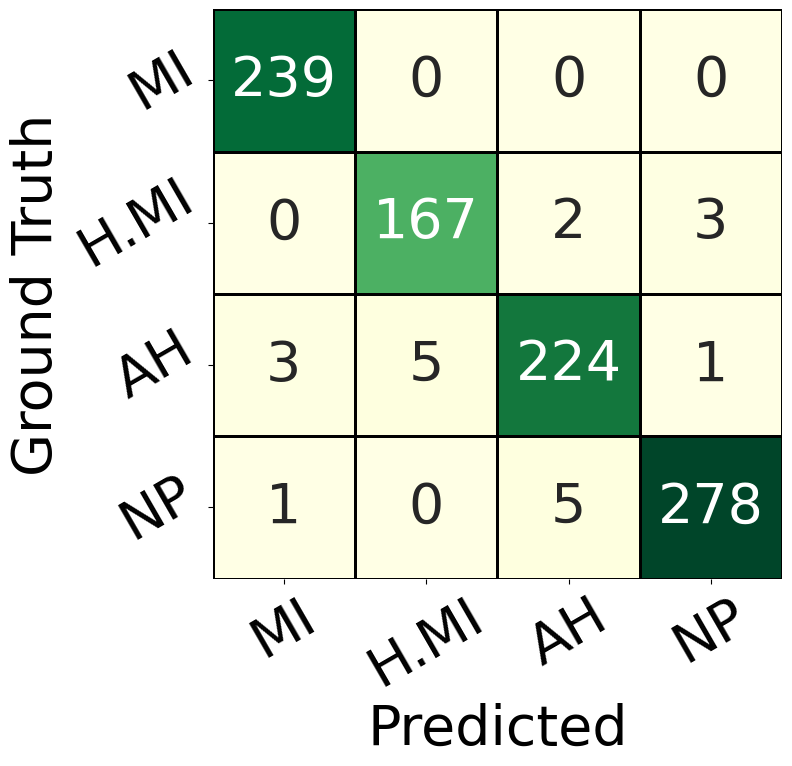

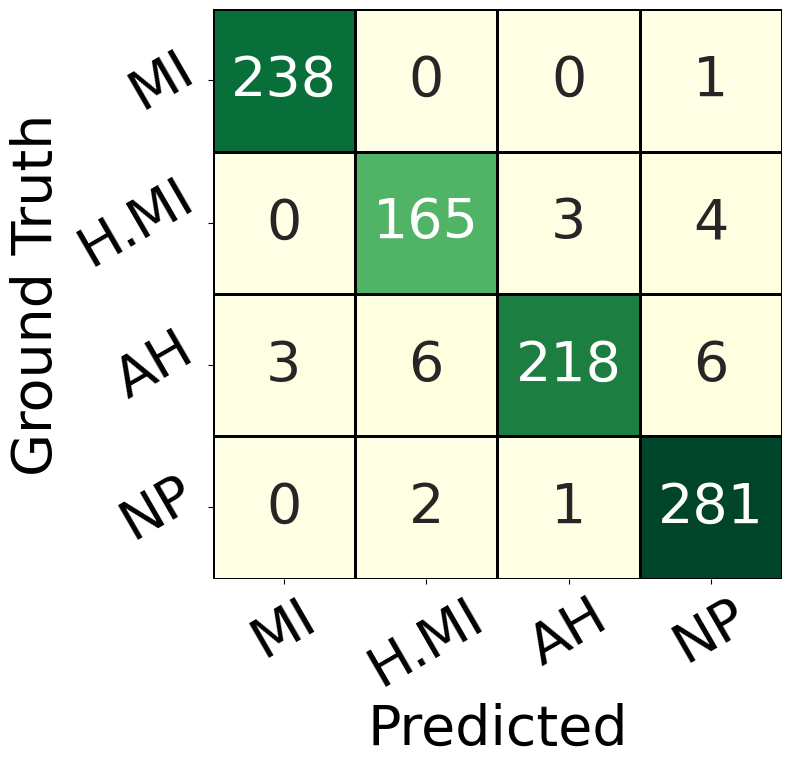

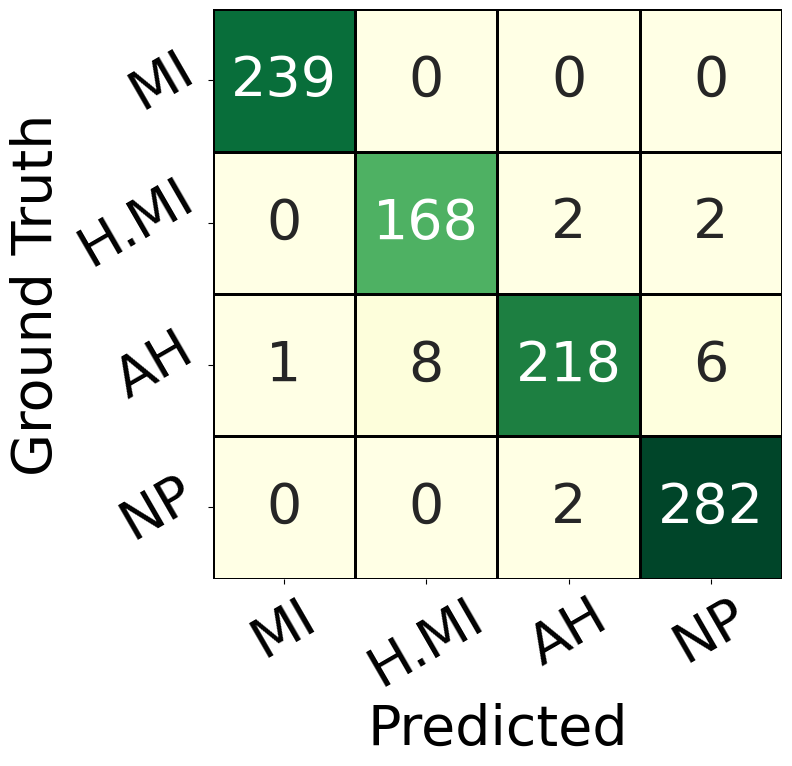

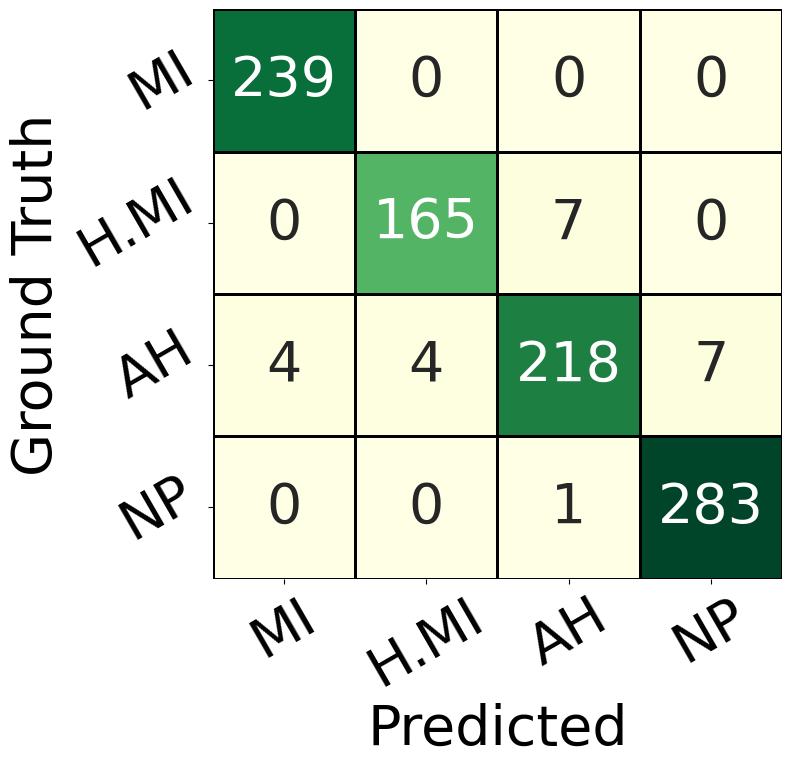

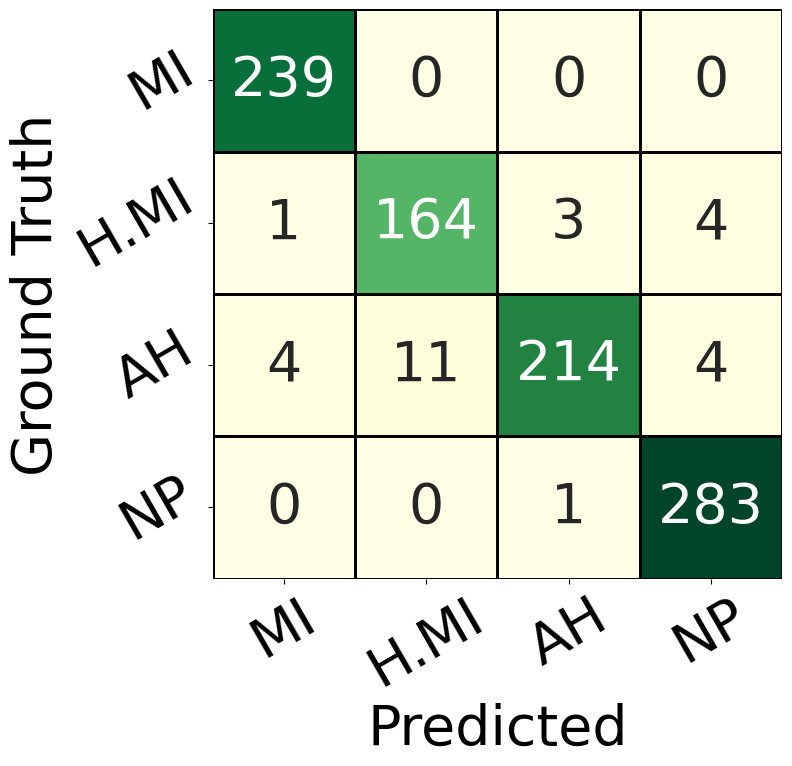

In [44]:
for backbone in BACKBONES:

    cm = confusion_matrices[backbone]


    plt.figure(
        figsize=(8,8)
    )
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGn",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=1,
        linecolor="black",
        cbar=False,
        square=True,
        annot_kws={
            "size":40
        }
    )
    
    plt.xlabel(
        "Predicted",
        fontsize=40
    )
    
    plt.ylabel(
        "Ground Truth",
        fontsize=40
    )
    
    plt.xticks(
        rotation=30,
        ha="center",
        fontsize=40
    )
    
    plt.yticks(
        rotation=30,
        fontsize=40
    )

    plt.tight_layout()
    
    plt.savefig(
        f"{backbone}_ConfusionMatrix.png",
        dpi=600,
        bbox_inches="tight"
    )
    
    plt.show()

In [48]:
import numpy as np
import matplotlib.pyplot as plt

BACKBONES = [
    "DenseNet169",
    "ResNet50",
    "VGG16",
    "VGG19",
    "MobileNetV2"
]

for backbone in BACKBONES:

    ###########################################################
    # Collect all folds
    ###########################################################

    train_losses = []
    val_losses = []
    test_losses = []

    for fold in range(5):

        history = master_histories[backbone][f"Fold{fold+1}"]

        train_losses.append(
            history["train_losses"]
        )

        val_losses.append(
            history["val_losses"]
        )

        test_losses.append(
            history["test_losses"]
        )

    ###########################################################
    # Mean across folds
    ###########################################################

    train_mean = np.mean(train_losses, axis=0)
    val_mean   = np.mean(val_losses, axis=0)
    test_mean  = np.mean(test_losses, axis=0)

    ###########################################################
    # Plot
    ###########################################################

    plt.figure(figsize=(7,5))

    plt.plot(
        train_mean,
        color="green",
        linewidth=3,
        label="Training"
    )

    plt.plot(
        val_mean,
        color="blue",
        linewidth=3,
        label="Validation"
    )

    plt.plot(
        test_mean,
        color="red",
        linewidth=3,
        label="Test"
    )

    plt.xlabel(
        "Epoch",
        fontsize=14
    )

    plt.ylabel(
        "Prototypical Loss",
        fontsize=14
    )

    plt.title(
        backbone,
        fontsize=16
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f"{backbone}_LossCurve.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

KeyError: 'DenseNet169'